# Pooled Dynamics Model Analysis

This notebook pools results from:
- single-transition fitting
- full-trajectory fitting
- trajectory-behavior evaluation

It builds panel-style comparisons and cross-objective rankings across all discovered models and conditions.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src/analysis/dynamics_model_fitting/outputs").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing dynamics_model_fitting outputs.")

PROJECT_ROOT = find_project_root(Path.cwd())
DMF_DIR = PROJECT_ROOT / "src/analysis/dynamics_model_fitting"
OUTPUTS_DIR = DMF_DIR / "outputs"
FIG_DIR = OUTPUTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUTS_DIR:", OUTPUTS_DIR)

PROJECT_ROOT: /Users/gs/Documents/GitHub/llm-debate-sim
OUTPUTS_DIR: /Users/gs/Documents/GitHub/llm-debate-sim/src/analysis/dynamics_model_fitting/outputs


In [3]:
BEHAV_RE = re.compile(
    r"(?P<model>m[\d-]+)__exp-(?P<experiment_group>[^_]+(?:_[^_]+)*)__graph-(?P<graph_type>[^_]+(?:-[^_]+)*)__"
    r"trans-(?P<exclude>false|true)__split-(?P<split>train|val|test)__match-(?P<match_mode>latest|all)__trajectory_behavior_summary\.parquet$"
)

def collect_behavior_metrics(fit_mode: str) -> pd.DataFrame:
    rows: list[dict] = []
    fit_root = OUTPUTS_DIR / fit_mode

    for path in sorted(fit_root.glob("m*/trajectory_behavior/*__trajectory_behavior_summary.parquet")):
        m = BEHAV_RE.search(path.name)
        if not m:
            continue

        try:
            summary = pd.read_parquet(path)
        except Exception:
            continue

        if summary.empty or "rollout_mode" not in summary.columns:
            continue

        base = {
            "fit_mode": fit_mode,
            "model": m.group("model"),
            "experiment_group": m.group("experiment_group"),
            "graph_type": m.group("graph_type"),
            "exclude_round0_to_1": m.group("exclude") == "true",
            "split": m.group("split"),
            "match_mode": m.group("match_mode"),
            "summary_path": str(path),
            "file_mtime": path.stat().st_mtime,
        }

        metric_cols = [
            c for c in summary.columns
            if c != "rollout_mode" and pd.api.types.is_numeric_dtype(summary[c])
        ]

        for _, r in summary.iterrows():
            for metric in metric_cols:
                value = r[metric]
                if pd.isna(value):
                    continue
                rows.append(
                    {
                        **base,
                        "rollout_mode": r["rollout_mode"],
                        "metric": metric,
                        "value": float(value),
                    }
                )

    return pd.DataFrame(rows)

behavior_df_raw = pd.concat(
    [collect_behavior_metrics("single_transitions"), collect_behavior_metrics("full_trajectories")],
    ignore_index=True,
)

behavior_key_cols = [
    "fit_mode",
    "model",
    "experiment_group",
    "graph_type",
    "exclude_round0_to_1",
    "split",
    "rollout_mode",
    "metric",
]
behavior_df = (
    behavior_df_raw.sort_values("file_mtime")
    .drop_duplicates(subset=behavior_key_cols, keep="last")
    .reset_index(drop=True)
)

print("Behavior rows (raw/latest):", len(behavior_df_raw), len(behavior_df))
behavior_df.head()

Behavior rows (raw/latest): 43320 43320


,fit_mode,model,experiment_group,graph_type,exclude_round0_to_1,split,match_mode,summary_path,file_mtime,rollout_mode,metric,value
0,single_transitions,m1,experts,erdos-renyi,False,train,latest,/Users/gs/Documents/GitHub/llm-debate-sim/src/...,1.778692e+09,deterministic,nontrivial_runs_only__frac_neg1_abs_error__point,0.023142
1,single_transitions,m1,experts,erdos-renyi,False,train,latest,/Users/gs/Documents/GitHub/llm-debate-sim/src/...,1.778692e+09,deterministic,all_runs__polarity_abs_error__ci_upper,0.291770
2,single_transitions,m1,experts,erdos-renyi,False,train,latest,/Users/gs/Documents/GitHub/llm-debate-sim/src/...,1.778692e+09,deterministic,nontrivial_runs_only__belief_mean_abs_error__p...,0.168222
3,single_transitions,m1,experts,erdos-renyi,False,train,latest,/Users/gs/Documents/GitHub/llm-debate-sim/src/...,1.778692e+09,deterministic,nontrivial_runs_only__belief_mean_abs_error__c...,0.147693
4,single_transitions,m1,experts,erdos-renyi,False,train,latest,/Users/gs/Documents/GitHub/llm-debate-sim/src/...,1.778692e+09,deterministic,nontrivial_runs_only__belief_mean_abs_error__c...,0.189905


In [4]:
# Consensus-only results for the filtered slice (full_trajectories, test, trans=alltrans).
consensus_metrics = [
    "all_runs__consensus_fraction_abs_error__point",
    "all_runs__consensus_fraction_abs_error__ci_lower",
    "all_runs__consensus_fraction_abs_error__ci_upper",
]

# Build per-run consensus rows, then aggregate across runs with quantile CIs.
consensus_df_raw = (
    behavior_df_raw.loc[
        (behavior_df_raw["split"] == "test")
        & (~behavior_df_raw["exclude_round0_to_1"])
        & (behavior_df_raw["rollout_mode"] == "stochastic")
        & (behavior_df_raw["match_mode"] == "latest")
        & (behavior_df_raw["fit_mode"] == "full_trajectories")
        & (behavior_df_raw["metric"].isin(consensus_metrics)),
        ["model", "experiment_group", "graph_type", "summary_path", "metric", "value"],
    ]
    .copy()
    .pivot(
        index=["model", "experiment_group", "graph_type", "summary_path"],
        columns="metric",
        values="value",
    )
    .reset_index()
    .dropna(
        subset=[
            "all_runs__consensus_fraction_abs_error__point",
            "all_runs__consensus_fraction_abs_error__ci_lower",
            "all_runs__consensus_fraction_abs_error__ci_upper",
        ]
    )
)

consensus_df_agg = (
    consensus_df_raw.groupby(["model", "experiment_group", "graph_type"], as_index=False)
    .agg(
        **{
            "all_runs__consensus_fraction_abs_error__point": (
                "all_runs__consensus_fraction_abs_error__point",
                "mean",
            ),
            "all_runs__consensus_fraction_abs_error__ci_lower": (
                "all_runs__consensus_fraction_abs_error__ci_lower",
                lambda s: float(np.percentile(s.to_numpy(dtype=float), 2.5)),
            ),
            "all_runs__consensus_fraction_abs_error__ci_upper": (
                "all_runs__consensus_fraction_abs_error__ci_upper",
                lambda s: float(np.percentile(s.to_numpy(dtype=float), 97.5)),
            ),
            "n_runs": ("summary_path", "nunique"),
        }
    )
    .sort_values(["model", "experiment_group", "graph_type"])
)

consensus_lfs = pl.from_pandas(consensus_df_agg).with_columns(
    [
        (1 - pl.col("all_runs__consensus_fraction_abs_error__point")).alias(
            "consensus_agreement_point"
        ),
        (1 - pl.col("all_runs__consensus_fraction_abs_error__ci_upper")).alias(
            "consensus_agreement_ci_lower"
        ),
        (1 - pl.col("all_runs__consensus_fraction_abs_error__ci_lower")).alias(
            "consensus_agreement_ci_upper"
        ),
    ]
)

consensus_lfs

model,experiment_group,graph_type,all_runs__consensus_fraction_abs_error__point,all_runs__consensus_fraction_abs_error__ci_lower,all_runs__consensus_fraction_abs_error__ci_upper,n_runs,consensus_agreement_point,consensus_agreement_ci_lower,consensus_agreement_ci_upper
str,str,str,f64,f64,f64,i64,f64,f64,f64
"""m1""","""base_llms""","""erdos-renyi""",0.089173,0.063836,0.11262,1,0.910827,0.88738,0.936164
"""m1""","""base_llms""","""watts-strogatz""",0.095644,0.073067,0.116639,1,0.904356,0.883361,0.926933
"""m1""","""experts""","""erdos-renyi""",0.263258,0.227586,0.293807,1,0.736742,0.706193,0.772414
"""m1""","""experts""","""watts-strogatz""",0.265862,0.21843,0.30439,1,0.734138,0.69561,0.78157
"""m1""","""random_experts""","""erdos-renyi""",0.278567,0.248179,0.30453,1,0.721433,0.69547,0.751821
…,…,…,…,…,…,…,…,…,…
"""m4""","""experts""","""watts-strogatz""",0.101957,0.082386,0.1209,1,0.898043,0.8791,0.917614
"""m4""","""random_experts""","""erdos-renyi""",0.062027,0.051766,0.074732,1,0.937973,0.925268,0.948234
"""m4""","""random_experts""","""watts-strogatz""",0.079072,0.066051,0.095015,1,0.920928,0.904985,0.933949


In [5]:
# MCC results for the same slice (full_trajectories, test, trans=alltrans), including CIs from logs.
FIT_RE = re.compile(
    r"(?P<model>m[\d-]+)__exp-(?P<experiment_group>[^_]+(?:_[^_]+)*)__graph-(?P<graph_type>[^_]+(?:-[^_]+)*)__trans-(?P<transition_tag>alltrans|exclude01)__"
    r"(?P<timestamp>\d{8}_\d{6})__results\.json$"
)

def _as_point_ci(metric_payload: object) -> tuple[float | None, float, float]:
    if isinstance(metric_payload, dict):
        point = metric_payload.get("point")
        ci_lower = metric_payload.get("ci_lower")
        ci_upper = metric_payload.get("ci_upper")
        if point is None:
            return None, np.nan, np.nan
        return (
            float(point),
            np.nan if ci_lower is None else float(ci_lower),
            np.nan if ci_upper is None else float(ci_upper),
        )
    if isinstance(metric_payload, (int, float)):
        return float(metric_payload), np.nan, np.nan
    return None, np.nan, np.nan

def _extract_mcc_with_ci(payload: dict) -> tuple[float | None, float, float]:
    metrics = payload.get("metrics", {})
    test_payload = metrics.get("test")
    if not isinstance(test_payload, dict):
        return None, np.nan, np.nan

    # Preferred path for full-trajectory logs.
    traj = test_payload.get("trajectory_fit_metrics")
    if isinstance(traj, dict) and "final_state_mcc" in traj:
        point, lo, hi = _as_point_ci(traj["final_state_mcc"])
        if point is not None:
            return point, lo, hi

    # Fallbacks: common MCC keys under transition metrics.
    trans = test_payload.get("transition_metrics")
    if isinstance(trans, dict):
        for k in ["final_state_mcc", "mcc"]:
            if k in trans:
                point, lo, hi = _as_point_ci(trans[k])
                if point is not None:
                    return point, lo, hi

    # Last-resort recursive search for final_state_mcc/mcc.
    stack = [test_payload]
    while stack:
        node = stack.pop()
        if isinstance(node, dict):
            for k, v in node.items():
                if k in {"final_state_mcc", "mcc"}:
                    point, lo, hi = _as_point_ci(v)
                    if point is not None:
                        return point, lo, hi
                if isinstance(v, dict):
                    stack.append(v)

    return None, np.nan, np.nan

mcc_rows = []
for path in sorted((OUTPUTS_DIR / "full_trajectories").glob("m*/**/*__results.json")):
    m = FIT_RE.search(path.name)
    if not m:
        continue
    if m.group("transition_tag") != "alltrans":
        continue

    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    mcc_point, mcc_ci_lower, mcc_ci_upper = _extract_mcc_with_ci(payload)
    if mcc_point is None:
        continue

    mcc_rows.append(
        {
            "model": m.group("model"),
            "experiment_group": m.group("experiment_group"),
            "graph_type": m.group("graph_type"),
            "timestamp": m.group("timestamp"),
            "mcc_point": mcc_point,
            "mcc_ci_lower": mcc_ci_lower,
            "mcc_ci_upper": mcc_ci_upper,
        }
    )

mcc_df = pd.DataFrame(mcc_rows)
if not mcc_df.empty:
    # Aggregate across runs per model/setting/graph using quantile-based CIs.
    mcc_df = (
        mcc_df.groupby(["model", "experiment_group", "graph_type"], as_index=False)
        .agg(
            mcc_point=("mcc_point", "mean"),
            mcc_ci_lower=("mcc_ci_lower", lambda s: float(np.percentile(s.to_numpy(dtype=float), 2.5))),
            mcc_ci_upper=("mcc_ci_upper", lambda s: float(np.percentile(s.to_numpy(dtype=float), 97.5))),
            n_runs=("mcc_point", "size"),
        )
        .sort_values(["model", "experiment_group", "graph_type"])
        .reset_index(drop=True)
    )

mcc_df.head()

,model,experiment_group,graph_type,mcc_point,mcc_ci_lower,mcc_ci_upper,n_runs
0,m1,base_llms,erdos-renyi,0.923571,0.900090,0.944570,1
1,m1,base_llms,watts-strogatz,0.902093,0.876586,0.926464,1
2,m1,experts,erdos-renyi,0.817016,0.784962,0.847433,1
3,m1,experts,watts-strogatz,0.796273,0.758788,0.830955,1
4,m1,random_experts,erdos-renyi,0.762997,0.727899,0.797013,1


In [10]:
# Figure: split panels into two separate 2x2 figures (Consensus and Final-state MCC).

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

# Style / fonts aligned with notebooks/plot_utils.py
def _configure_fonts() -> None:
    desired_fonts = {
        "serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "monospace": ["Courier New", "Courier", "DejaVu Sans Mono"],
    }

    mpl.rcParams.update(
        {
            "text.usetex": False,
            "font.family": "sans-serif",
            "font.serif": desired_fonts["serif"][0],
            "font.sans-serif": desired_fonts["sans-serif"][0],
            "font.monospace": desired_fonts["monospace"][0],
            "axes.titlesize": 12,
            "axes.labelsize": 13,
            "xtick.labelsize": 11,
            "ytick.labelsize": 11,
            "legend.fontsize": 11,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )

_configure_fonts()
sns.set_theme(style="whitegrid", context="talk")

OKABE_ITO = {
    "yellow": "#F0E442",
    "sky": "#56B4E9",
    "blue": "#0072B2",
    "vermilion": "#D55E00",
    "green": "#009E73",
    "orange": "#E69F00",
    "purple": "#CC79A7",
    "black": "#000000",
}

GRAPH_MAP = {
    "erdos-renyi": "Erdős-Rényi",
    "watts-strogatz": "Watts-Strogatz",
}
GRAPH_COLOR = {
    "erdos-renyi": OKABE_ITO["purple"],
    "watts-strogatz": OKABE_ITO["green"],
}

SETTING_MAP = {
    "base_llms": "I. Base LLMs",
    "random_roles": "II. Random roles",
    "random_experts": "III. Spcs (random)",
    "experts": "IV. Spcs (matching)",
}

OPMOD_MAP = {
    "m1": "M1",
    "m2-5": "M2",
    "m3": "M3",
    "m4": "M4",
}

plot_df_graph = consensus_lfs.select(
    [
        "model",
        "experiment_group",
        "graph_type",
        "consensus_agreement_point",
        "consensus_agreement_ci_lower",
        "consensus_agreement_ci_upper",
    ]
).to_pandas()

plot_df_graph = plot_df_graph.merge(
    mcc_df[["model", "experiment_group", "graph_type", "mcc_point", "mcc_ci_lower", "mcc_ci_upper"]],
    on=["model", "experiment_group", "graph_type"],
    how="left",
)

merged_plot_data_path = FIG_DIR / "pooled_plot_data_merged.csv"
plot_df_graph.to_csv(merged_plot_data_path, index=False)
print("Saved merged plot data:", merged_plot_data_path)

setting_order = ["base_llms", "random_roles", "random_experts", "experts"]
graph_order = ["erdos-renyi", "watts-strogatz"]
preferred_model_order = ["m1", "m2-5", "m3", "m4"]
model_order = [m for m in preferred_model_order if m in plot_df_graph["model"].unique()]

x = np.arange(len(model_order))
offsets = {"erdos-renyi": -0.07, "watts-strogatz": 0.07}

mcc_min = float(plot_df_graph["mcc_point"].min()) if plot_df_graph["mcc_point"].notna().any() else -1.0
mcc_max = float(plot_df_graph["mcc_point"].max()) if plot_df_graph["mcc_point"].notna().any() else 1.0
mcc_pad = max(0.02, 0.08 * (mcc_max - mcc_min if mcc_max > mcc_min else 0.2))
mcc_ylim = (max(-1.0, mcc_min - mcc_pad), 1.0)

graph_handles = [
    Line2D([0], [0], color=GRAPH_COLOR[g], marker="o", linestyle="-", lw=2.2, ms=7, label=GRAPH_MAP[g])
    for g in graph_order
]

FIG_SIZE = (6.5, 5.5)
SERIES_FMT = "o-"
SERIES_LINEWIDTH = 2.0
SERIES_MARKERSIZE = 4
SERIES_CAPSIZE = 4
SERIES_ALPHA = 0.95
PANEL_LABEL_X_LEFT = -0.30
PANEL_LABEL_X_RIGHT = -0.24
PANEL_LABEL_Y = 1.10
PANEL_LABEL_SIZE = 14
LEGEND_BBOX_Y = -0.03

def _style_axis(ax):
    ax.set_xticks(x)
    ax.set_xticklabels([OPMOD_MAP.get(m, m) for m in model_order])
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=1)
    ax.grid(axis="x", visible=False)
    for xv in x:
        ax.axvline(
            x=xv,
            color=OKABE_ITO["black"],
            linestyle=(0, (1.0, 3.0)),
            linewidth=1.0,
            alpha=0.40,
            dash_capstyle="round",
            zorder=0,
        )
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(OKABE_ITO["black"])
    ax.spines["bottom"].set_color(OKABE_ITO["black"])
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        bottom=True,
        top=False,
        left=True,
        right=False,
        width=1.3,
        length=6,
        color=OKABE_ITO["black"],
        labelcolor=OKABE_ITO["black"],
    )
    ax.xaxis.label.set_color(OKABE_ITO["black"])
    ax.yaxis.label.set_color(OKABE_ITO["black"])
    ax.title.set_color(OKABE_ITO["black"])
    ax.tick_params(axis="x", which="major", labelsize=12)
    ax.tick_params(axis="y", which="major", labelsize=12)

panel_labels = ["A", "B", "C", "D"]

def plot_2x2(
    df, y_col, yerr_lo_col, yerr_hi_col,
    ylabel, ylim, save_path
):
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE, sharex=False, sharey=False)
    for i, setting in enumerate(setting_order):
        ax = axes[i // 2, i % 2]
        panel = df[df["experiment_group"] == setting]
        for graph in graph_order:
            sub = (
                panel[panel["graph_type"] == graph]
                .set_index("model").reindex(model_order).reset_index()
            )
            xs = x + offsets[graph]
            y = sub[y_col].to_numpy(dtype=float)
            lo = y - sub[yerr_lo_col].to_numpy(dtype=float)
            hi = sub[yerr_hi_col].to_numpy(dtype=float) - y
            kw = dict(fmt=SERIES_FMT, color=GRAPH_COLOR[graph], lw=SERIES_LINEWIDTH,
                      ms=SERIES_MARKERSIZE, capsize=SERIES_CAPSIZE, alpha=SERIES_ALPHA)
            if np.isfinite(lo).any() and np.isfinite(hi).any():
                ax.errorbar(xs, y, yerr=[lo, hi], **kw)
            else:
                ax.plot(xs, y, linestyle="-", marker="o",
                        color=GRAPH_COLOR[graph], lw=SERIES_LINEWIDTH,
                        ms=SERIES_MARKERSIZE, alpha=SERIES_ALPHA)

        ax.set_title(SETTING_MAP.get(setting, setting))
        _style_axis(ax)
        px = PANEL_LABEL_X_RIGHT if i % 2 == 1 else PANEL_LABEL_X_LEFT
        ax.text(px, PANEL_LABEL_Y, panel_labels[i], transform=ax.transAxes,
                ha="left", va="bottom", fontsize=PANEL_LABEL_SIZE,
                fontweight="bold", color=OKABE_ITO["black"])
        ax.set_ylim(ylim)
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    for row in range(2):
        axes[row, 0].set_ylabel(ylabel)

    fig.legend(graph_handles, [h.get_label() for h in graph_handles],
               loc="lower center", bbox_to_anchor=(0.5, LEGEND_BBOX_Y),
               ncol=2, frameon=False)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.14, wspace=0.3)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", save_path)

Saved merged plot data: /Users/gs/Documents/GitHub/llm-debate-sim/src/analysis/dynamics_model_fitting/outputs/figures/pooled_plot_data_merged.csv


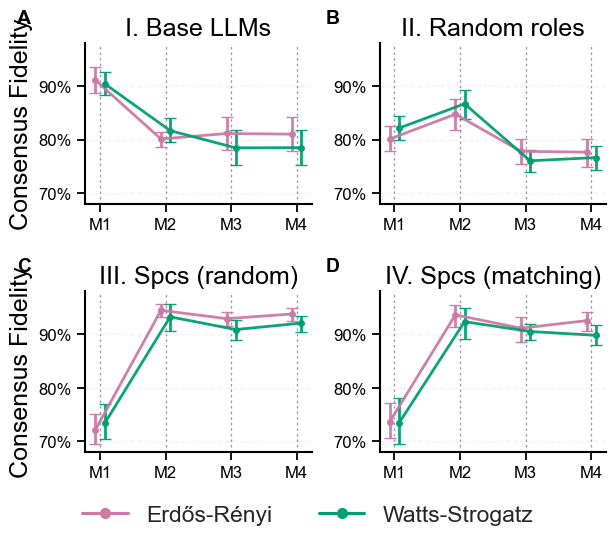

Saved: /Users/gs/Documents/GitHub/llm-debate-sim/src/analysis/dynamics_model_fitting/outputs/figures/pooled_consensus.pdf


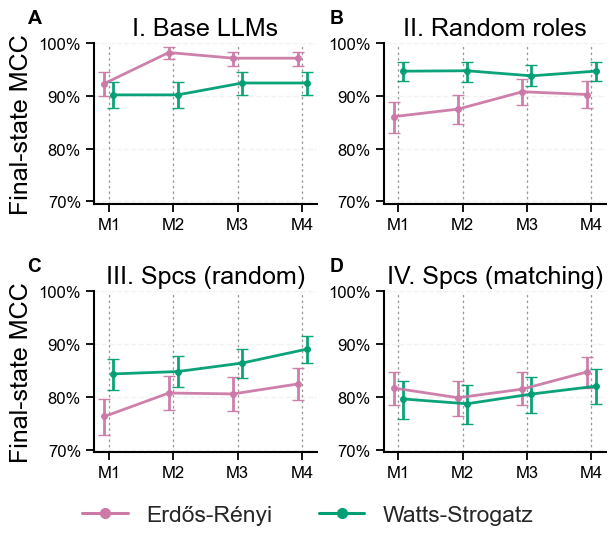

Saved: /Users/gs/Documents/GitHub/llm-debate-sim/src/analysis/dynamics_model_fitting/outputs/figures/pooled_final_state_mcc.pdf


In [11]:
plot_2x2(
    plot_df_graph,
    y_col="consensus_agreement_point",
    yerr_lo_col="consensus_agreement_ci_lower",
    yerr_hi_col="consensus_agreement_ci_upper",
    ylabel="Consensus Fidelity",
    ylim=(0.68, 0.98),
    save_path=FIG_DIR / "pooled_consensus.pdf",
)

plot_2x2(
    plot_df_graph,
    y_col="mcc_point",
    yerr_lo_col="mcc_ci_lower",
    yerr_hi_col="mcc_ci_upper",
    ylabel="Final-state MCC",
    ylim=mcc_ylim,
    save_path=FIG_DIR / "pooled_final_state_mcc.pdf",
)